# Introduction

Objective of this notebook is to explore customer behaviour, sales performance and operational metrics using the analytical datasets prepared in PostgreSQL.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Load

In [2]:
from src.database import load_view

df_customers = load_view("vw_customer_summary_python")
df_monthly_sales = load_view("vw_monthly_sales_summary")
df_products = load_view("vw_products_summary")
df_delivery = load_view("vw_delivery_summary")
df_reviews = load_view("vw_order_review_summary")

# Monthly Sales Summary Overview

In [9]:
df_monthly_sales.tail()

,purchase_month,total_orders,total_customers,total_revenue,avg_order_value,avg_orders_per_customer,cancelled_orders,cancellation_rate,unavailable_orders,unavailable_rate
20,2018-06-01,6167,6128,1023880.50,166.03,1,18,0.29,4,0.06
21,2018-07-01,6292,6230,1066540.75,169.51,1,41,0.65,18,0.29
22,2018-08-01,6512,6460,1022425.32,157.01,1,84,1.29,7,0.11
23,2018-09-01,16,14,4439.54,277.47,1,15,93.75,0,0.00
24,2018-10-01,4,4,589.67,147.42,1,4,100.00,0,0.00


Dataset ends in August 2018, all data in September and October represent transactions whose processing or cancellation was delayed in system time and should be excluded from trend analysis.

In [10]:
df_monthly_sales_clean = df_monthly_sales[df_monthly_sales['purchase_month'] < '2018-09-01']

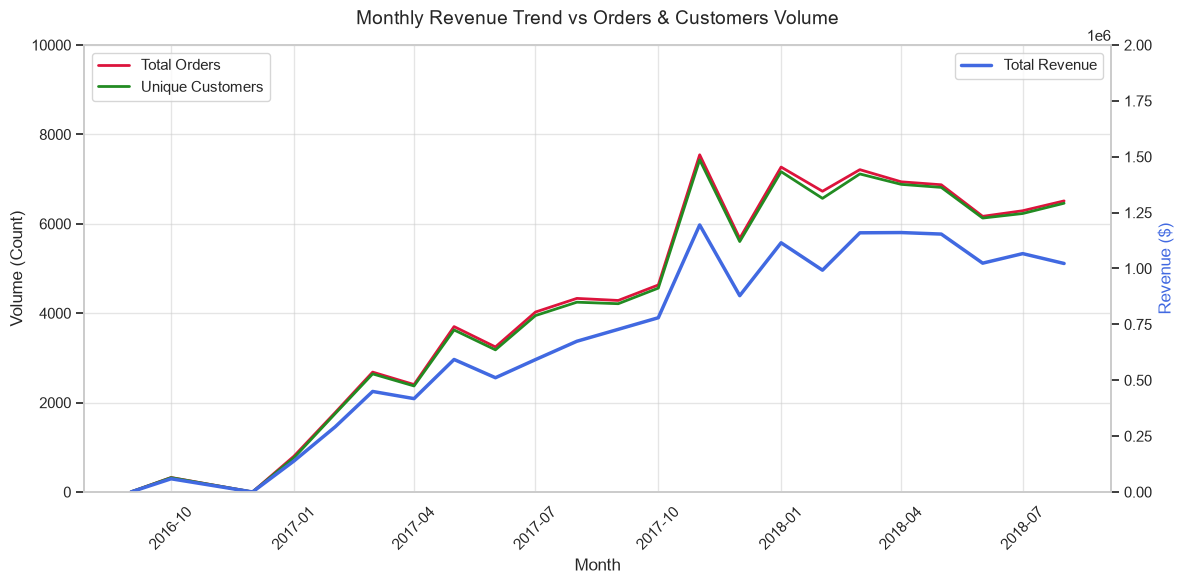

In [25]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='total_orders',
             ax=ax1, color='crimson', label='Total Orders', linewidth=2)
sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='total_customers',
             ax=ax1, color='forestgreen', label='Unique Customers', linewidth=2)

ax1.set_ylabel('Volume (Count)')
ax1.set_ylim(0,10000)
ax1.set_xlabel('Month')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='total_revenue',
             ax=ax2, color='royalblue', label='Total Revenue', linewidth=2.5)

ax2.set_ylabel('Revenue ($)', color='royalblue')
ax2.set_ylim(0,2000000)
ax2.grid(False)
ax2.legend(loc='upper right')

plt.title('Monthly Revenue Trend vs Orders & Customers Volume', fontsize=14, pad=15)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The near-identical alignment between unique customers and total orders highlights a low retention rate, proving the business relies almost entirely on new customers. Furthermore, since the revenue trend scales proportionally with order volume, growth remains linear rather than exponential, indicating that the platform's monetary performance is entirely bound to scaling transaction numbers.

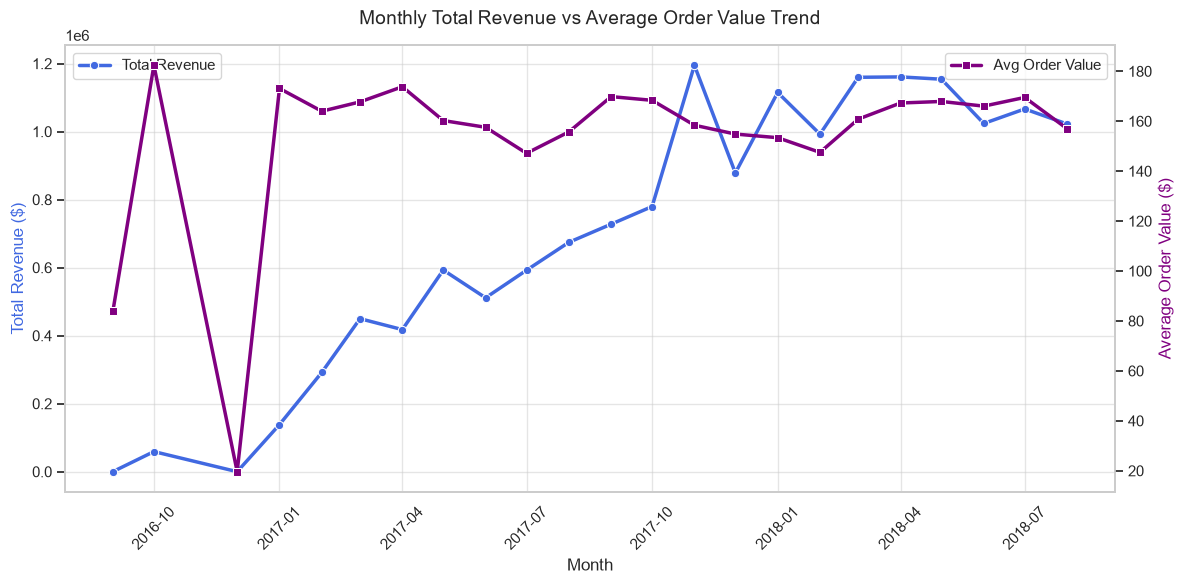

In [27]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='total_revenue',
             ax=ax1, color='royalblue', label='Total Revenue', linewidth=2.5)

ax1.set_ylabel('Total Revenue ($)', color='royalblue')
ax1.set_xlabel('Month')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='avg_order_value',
             ax=ax2, color='purple', label='Avg Order Value', linewidth=2.5)

ax2.set_ylabel('Average Order Value ($)', color='purple')
ax2.grid(False)
ax2.legend(loc='upper right')

plt.title('Monthly Total Revenue vs Average Order Value Trend', fontsize=14, pad=15)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Comparison of Total Revenue and Average Order Value further supports that business scales through volume as Average Order Value remains almost flat throughout analyzed period.

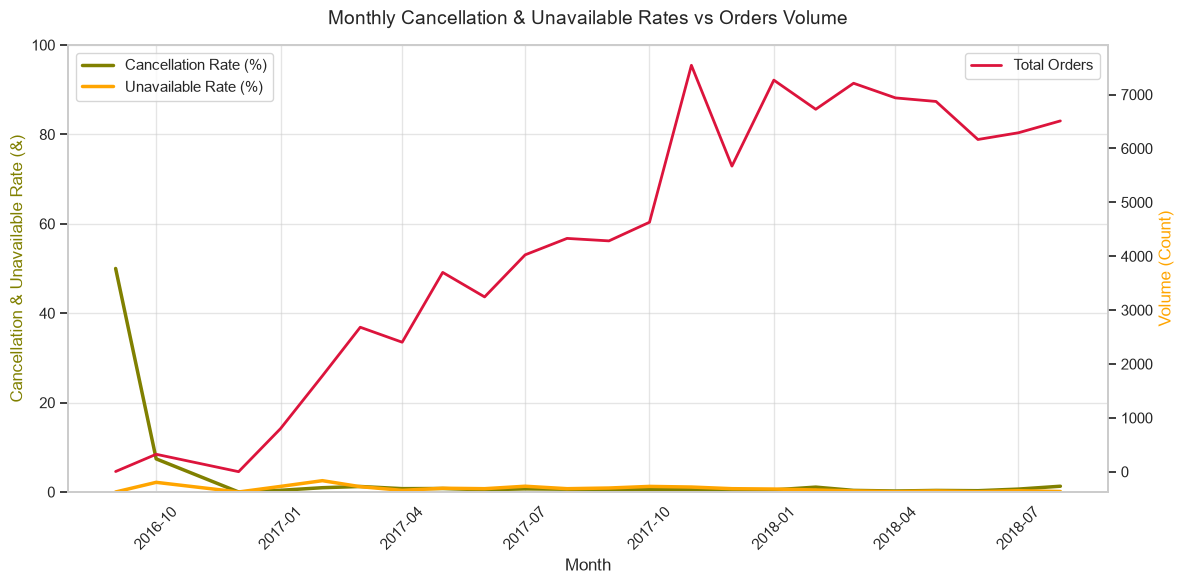

In [33]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='cancellation_rate',
             ax=ax1, color='olive', label='Cancellation Rate (%)', linewidth=2.5)
sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='unavailable_rate',
             ax=ax1, color='orange', label='Unavailable Rate (%)', linewidth=2.5)

ax1.set_ylabel('Cancellation & Unavailable Rate (&)', color='olive')
ax1.set_ylim(0,100)
ax1.set_xlabel('Month')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='total_orders',
             ax=ax2, color='crimson', label='Total Orders', linewidth=2)

ax2.set_ylabel('Volume (Count)', color='orange')
ax2.grid(False)
ax2.legend(loc='upper right')

plt.title('Monthly Cancellation & Unavailable Rates vs Orders Volume', fontsize=14, pad=15)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

While total orders scaled significantly, the cancellation and unavailable rates remained consistently stable and low, indicating efficient order processing during periods of high volume.